# Zasilmy nasz model wiedzą z pliku PDF

## Jak zwykle importy

In [10]:
import abc
import os

from dotenv import load_dotenv
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

load_dotenv('../.env')

True

## Co rozumiemy przez Knowledge Base?

In [11]:
class KnowledgeBase(abc.ABC):
    @abc.abstractmethod
    def add_txt_to_vectorstore(self, file) -> bool:
        """Process PDF file and add its content to the vectorstore."""
        pass

    @abc.abstractmethod
    def search(self, query: str, k: int = 3) -> list[Document]:
        """Search the vectorstore for relevant documents based on the query."""
        pass

## Snippety

In [114]:
# jak wczytywać plik CSV
...

# jak splitować text
# chunks = self.text_splitter.split_text(full_text)

# jak dodawać dokumenty do vectorstore
# documents = [Document(page_content=chunk) for chunk in chunks]
# self.vectorstore.add_documents(documents)

## **[Zadanie]** Uzupełnij klasę `InMemoryKnowledgeBase` aby mogła przetwarzać pliki CSV i dodawać je do `InMemoryVectorStore`

In [12]:
class InMemoryKnowledgeBase(KnowledgeBase):
    def __init__(self, openai_api_key):
        self.vectorstore = InMemoryVectorStore(
            OpenAIEmbeddings(model="text-embedding-3-small", openai_api_key=openai_api_key))
        self.text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=20)

    def add_txt_to_vectorstore(self, file) -> bool:
        try:
            # tego tu nie będzie :)
            with open(file, 'r', encoding='utf-8') as f:
                full_text = f.read()
            self.vectorstore.add_documents([Document(page_content=chunk) for chunk in self.text_splitter.split_text(full_text)])
            return True
        except Exception as e:
            print(f"Error processing PDF: {e}")  # Log the error for debugging
            return False

    def search(self, query: str, k: int = 3) -> list[Document]:
        return self.vectorstore.similarity_search(query, k=k)

knowledge_base = InMemoryKnowledgeBase(os.getenv('OPENAI_API_KEY'))
knowledge_base.add_txt_to_vectorstore('../data/sample.txt')
knowledge_base.add_txt_to_vectorstore('../data/paracetamol.txt')
knowledge_base.add_txt_to_vectorstore('../data/woman_in_tech_agenda.txt')

# tutaj trzeba pyknać jakiś assert czy to co ktoś napisał ma sens

True

## Potestujmy searcha

In [13]:
def show_docs(retrieved_documents):
    print(''.join([f"\n-----------------\nDoc nr {i+1}:\n-----------------\n {d.page_content}" for i, d in enumerate(retrieved_documents)]))

print("###########")
print("# chatbot #")
print("###########\n")
show_docs(knowledge_base.search("chatbot"))
print("\n=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=\n")
print("###############")
print("# paracetamol #")
print("###############\n")
show_docs(knowledge_base.search("paracetamol"))

###########
# chatbot #
###########


-----------------
Doc nr 1:
-----------------
 To co? Stworzymy wspólnie Twój pierwszy AI-owy chatbot w Pythonie? 

Tags:

- Artificial Intelligence
- Automation
- Data Management
- Generative AI
- Machine Learning
- New Technology
- Telecommunications
-----------------
Doc nr 2:
-----------------
 ## Zbuduj AI Chatbota w Pythonie!

Chcesz zrozumieć, jak działają nowoczesne chatboty oparte na sztucznej inteligencji i sama stworzyć jednego z nich? Podczas tego warsztatu krok po kroku zbudujesz własnego AI chatbota wykorzystującego technikę RAG (Retrieval-Augmented Generation) – jedną z najciekawszych innowacji w świecie generatywnej AI.

Nauczysz się:

- czym jest RAG i jak łączy modele językowe z danymi zewnętrznymi,
- jak przygotować własne dane (np. PDF-y, artykuły) do wykorzystania przez bota,
- jak stworzyć działającego chatbota, który naprawdę "wie, o czym mówi",
- i jak to wszystko zintegrować w prostym projekcie (np. przy użyciu Streamlit lu

## Podejrzymy jakie są chunki w vector storze

In [14]:
import pandas as pd
data_df = pd.DataFrame(knowledge_base.vectorstore.store.values(), columns=['id', 'text'])
pd.set_option('display.max_colwidth', None)
data_df
# pd.reset_option('display.max_columns')

,id,text
0,15ff2dd6-cc39-4fee-8448-7524040aeb64,"To jest przykładowy plik tekstowy używany do warsztatów z RAG.\nZawiera informacje, które chatbot będzie mógł przeszukiwać."
1,499ddfd9-5ee1-4f91-8935-c713e0a9e364,"1\nUlotka dołączona do opakowania: informacja dla użytkownika\nPARACETAMOL DOZ, 500 mg, tabletki\nParacetamolum\nNależy uważnie zapoznać się z treścią ulotki przed zażyciem leku, ponieważ zawiera ona informacje\nważne dla pacjenta.\nLek ten należy zawsze przyjmować dokładnie tak, jak to opisano w ulotce dla pacjenta lub według zaleceń\nlekarza,farmaceuty lub pielęgniarki.\n- Należy zachować tę ulotkę, aby w razie potrzeby móc ją ponownie przeczytać.\n- Jeśli potrzebna jest rada lub dodatkowa informacja, należy zwrócić się do farmaceuty.\n- Jeśli u pacjenta wystąpią jakiekolwiek objawy niepożądane, w tym wszelkie możliwe objawy\nniepożądane niewymienione w ulotce, należy powiedzieć o tym lekarzowi, farmaceucie lub\npielęgniarce. Patrz punkt 4.\n- Jeśli po upływie 3 dni nie nastąpiła poprawa lub pacjent czuje się gorzej, należy skontaktować się\nz lekarzem.\nSpis treści ulotki\n1. Co to jest lek Paracetamol DOZ i w jakim celu się go stosuje\n2. Informacje ważne przed przyjęciem leku Paracetamol DOZ"
2,28d08a43-1db5-4fb2-b506-97b269a92784,"3. Jak przyjmować lek Paracetamol DOZ\n4. Możliwe działania niepożądane\n5. Jak przechowywać lek Paracetamol DOZ\n6. Zawartość opakowania i inne informacje\n1. Co to jest lek Paracetamol DOZ i w jakim celu się go stosuje\nParacetamol DOZ jest lekiem przeciwbólowym i przeciwgorączkowym. Lek stosowany jest w leczeniu: bólu\ngłowy, bólu gardła, migreny, bólu zębów, bólów kostnych, stawowych i mięśniowych, bolesnego\nmiesiączkowania. Ponadto, lek może być stosowany w przeziębieniach oraz w stanach grypopodobnych.\nJeśli po upływie 3 dni nie nastąpiła poprawa lub pacjent czuje się gorzej, należy zwrócić się do lekarza.\n2. Informacje ważne przed przyjęciem leku Paracetamol DOZ\nKiedy nie przyjmować leku Paracetamol DOZ:\n- jeśli u pacjenta stwierdzono uczulenie (nadwrażliwość) na paracetamol lub którykolwiek z pozostałych\nskładników tego leku (wymienionych w punkcie 6),\n- jeśli pacjent cierpi na chorobę alkoholową,\n- jeśli u pacjenta występuje ciężka niewydolność wątroby lub nerek."
3,328cd88c-e17d-45cf-8a73-b67dffe9cb26,"Ostrzeżenia i środki ostrożności\nPrzed rozpoczęciem przyjmowania leku Paracetamol DOZ należy omówić to z lekarzem, farmaceutą lub\npielęgniarką.\nKiedy zachować szczególne środki ostrożności stosując lek Paracetamol DOZ:\n- jeśli pacjent cierpi na zaburzenia czynności wątroby i (lub) nerek,\n- u pacjentów z niedoborem białka zwanego dehydrogenazą glukozo-6-fosforanową (u tych pacjentów może\ndojść do uszkodzenia krwinek czerwonych) i reduktazy methemoglobinowej,\n- w czasie przyjmowania leku nie należy pić alkoholu, ponieważ może to doprowadzić do uszkodzenia\nwątroby; zwiększone ryzyko uszkodzenia wątroby występuje u osób regularnie spożywających alkohol oraz\nu osób głodzonych,\n2\n- ze względu na możliwość przedawkowania paracetamolu, nie należy zażywać równocześnie innych leków\nzawierających paracetamol.\nParacetamol DOZ a inne leki\nNależy powiedzieć lekarzowi, farmaceucie o wszystkich lekach przyjmowanych przez pacjenta obecnie lub"
4,8de5320a-e68e-4451-aa24-84779b8a3629,"ostatnio, a także o lekach, które pacjent planuje przyjmować.\n Leki przyspieszające opróżnianie żołądka (np. metoklopramid, domperidon) mogą zwiększać\nwchłanianie paracetamolu.\n Cholestyramina (lek obniżający stężenie cholesterolu we krwi) może zmniejszać wchłanianie\nparacetamolu.\n Regularne codzienne zażywanie paracetamolu może nasilać działanie leków przeciwzakrzepowych\n(z grupy kumaryny), co może doprowadzić do wystąpienia krwawień.\n Równoczesne stosowanie paracetamolu i leków zwiększających metabolizm wątrobowy, np.\nniektórych leków nasennych lub przeciwpadaczkowych (np. fenobarbital, fenytoina, karbamazepina)\noraz rifampicyny (antybiotyk) może prowadzić do uszkodzenia wątroby

## Narysujmy chunki w 2D

/home/m/projects/all-rag-techniques/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 61607 (\uf0a7) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


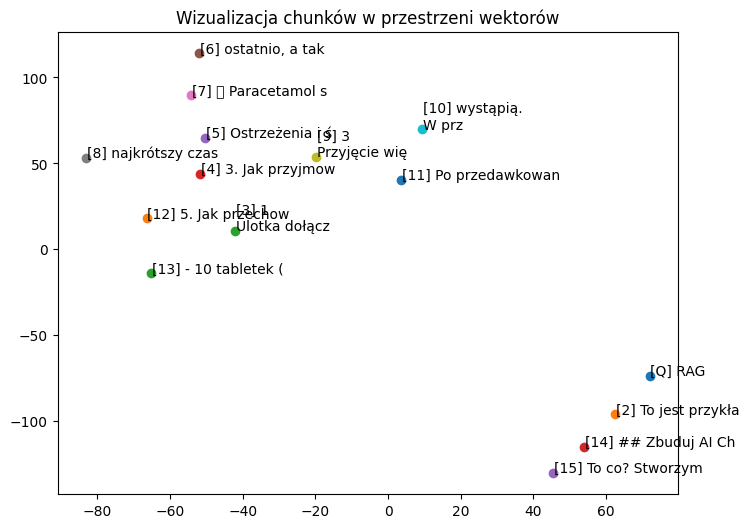

In [26]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

vectors = list(map(lambda x: x['vector'], knowledge_base.vectorstore.store.values()))
vectors_labels = list(map(lambda x: x['text'][:15], knowledge_base.vectorstore.store.values()))
question = 'RAG'
question_vector = knowledge_base.vectorstore.embeddings.embed_documents([question])

tsne = TSNE(n_components=2, perplexity=3, random_state=42)
embeddings_2d = tsne.fit_transform(np.array(question_vector + vectors))

plt.figure(figsize=(8,6))
for i, point in enumerate(embeddings_2d):
    plt.scatter(point[0], point[1])
    if i == 0:
        plt.annotate(f"[Q] {question}", (point[0]+0.2, point[1]+0.2))
    else:
        plt.annotate(f"[{i+1}] {vectors_labels[i-1]}", (point[0]+0.2, point[1]+0.2))

plt.title("Wizualizacja chunków w przestrzeni wektorów")
plt.show()